In [10]:
import numpy as np
import scipy.io
from tqdm import tqdm
import h5py
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [3]:
# import h5py
# print(h5py.__version__)
# print(h5py.version.info)

In [3]:
# import numpy as np
# import scipy.io
# from tqdm import tqdm

# # Parameters
# N = 800
# Pf = 0.8
# Pn = 0.4
# variance = 0.1
# num_iterations = 50000

# # Symbol sets
# symbol_bpsk = np.array([-1+0j, 1+0j])
# theta1 = np.cos(np.pi/8) + 1j*np.sin(np.pi/8)
# symbol_qpsk = theta1 * np.array([0.7071+0.7071j, -0.7071+0.7071j, 0.7071-0.7071j, -0.7071-0.7071j])
# symbol_8psk = np.array([1, 0.7071+0.7071j, 1j, -0.7071+0.7071j, -1, -0.7071-0.7071j, -1j, 0.7071-0.7071j])
# qam = np.array([-1-1j, 1-1j, 1+1j, -1+1j, -3-1j, -1-3j, 1-3j, 3-1j,
#                 3+1j, 1+3j, -1+3j, -3+1j, -3-3j, 3-3j, 3+3j, -3+3j])
# qam16 = qam.reshape(-1, 1)
# sqrt_mean = np.sqrt(np.mean(np.abs(qam16)**2))
# symbol_16qam = qam16 / sqrt_mean

# # Set of symbols
# setof_symbs = [symbol_bpsk, symbol_qpsk, symbol_8psk, symbol_16qam]

# # Data storage
# true_lbls = np.zeros(num_iterations)
# data_y = np.zeros((num_iterations, N), dtype=complex)
# all_snrs = np.zeros(num_iterations)
# all_h = np.zeros(num_iterations)

# snrs = []
# data_Y = []
# true_Mods = []

# # Simulation loop
# for snr_db in tqdm(range(-10, 21, 2), desc="Processing SNR"):
#     snr = 10**(snr_db/10)
    
#     for iter in tqdm(range(num_iterations), desc="Iterations", leave=False):
#         xr = np.random.randn()
#         yi = np.random.randn()
#         h = np.sqrt(variance * (xr**2 + yi**2))
#         all_h[iter] = h
        
#         i = np.random.randint(0, 4)
#         true_lbls[iter] = i
#         j = np.random.randint(0, 4)
        
#         symb_far = setof_symbs[i]
#         symb_near = setof_symbs[j]
        
#         xf = np.random.choice(symb_far.flatten(), N, replace=True)
#         xn = np.random.choice(symb_near.flatten(), N, replace=True)
        
#         y0 = h * (np.sqrt(Pf) * xf + np.sqrt(Pn) * xn)
#         ps = np.sum(np.abs(y0)**2) / len(y0)
        
#         noisepower = ps / snr
#         z = np.sqrt(noisepower * 0.5) * (np.random.randn(N) + 1j * np.random.randn(N))
#         pn = np.sum(np.abs(z)**2) / len(z)
#         y = y0 + z
        
#         snr_y = ps / pn
#         all_snrs[iter] = snr_y
#         data_y[iter, :] = y
    
#     snrs.extend([snr_db] * num_iterations)
#     data_Y.append(data_y.copy())
#     true_Mods.extend(true_lbls.copy())

# data_Y = np.vstack(data_Y)
# true_Mods = np.array(true_Mods)

# # import h5py

# # # File name
# # file_name = 'dataset_NOMA_N_800_1_2.h5'

# # # Save to HDF5
# # with h5py.File(file_name, 'w') as hf:
# #     hf.create_dataset('data_Y', data=data_Y)
# #     hf.create_dataset('true_Mods', data=true_Mods)
# #     hf.create_dataset('snrs', data=snrs)

# # print(f"Dataset saved as '{file_name}'")


In [2]:
# import h5py

# # File name
# file_name = 'dataset_NOMA_N_800_1_2.h5'

# # Save to HDF5
# with h5py.File(file_name, 'w') as hf:
#     hf.create_dataset('data_Y', data=data_Y)
#     hf.create_dataset('true_Mods', data=true_Mods)
#     hf.create_dataset('snrs', data=snrs)

# print(f"Dataset saved as '{file_name}'")

In [4]:
import h5py

# File name
file_name = 'dataset_NOMA_N_800_1_2.h5'

# Access and print the data
with h5py.File(file_name, 'r') as hf:
    data_Y = hf['data_Y'][:,:200]
    true_Mods = hf['true_Mods'][:]
    snrs = hf['snrs'][:]
    print(f"Shape of data_Y: {data_Y.shape}")
    print(f"Shape of true_Mods: {true_Mods.shape}")
    print(f"Shape of snrs: {snrs.shape}")

# print("data_Y:",data_Y.shape, data_Y[0].shape)
# print("data_Y:", data_Y[0][799])
# print("true_Mods:", true_Mods[:])
# print("snrs:", snrs[:])

Shape of data_Y: (800000, 200)
Shape of true_Mods: (800000,)
Shape of snrs: (800000,)


In [2]:
# print("data_Y:", data_Y[0][:])

#### Shape of data_Y: (800000, 800)
#### Shape of true_Mods: (800000,)
#### Shape of snrs: (800000,)
#### Each signal 800 Point : Total 800000 Signals : both Real & Imaginary in same column
#### shape of data_Y[i] : i X 800

In [4]:
import matplotlib.pyplot as plt

#  Signal
signal = data_Y[0][:50]

# plt.figure(figsize=(12, 6))
# # plt.subplot(2, 1, 1)
# plt.plot(signal.real, label='Real Part', color='blue')
# plt.title('Real Part of data_Y[0]')
# plt.xlabel('Sample Index')
# plt.ylabel('Amplitude')
# plt.legend()

# # plt.subplot(2, 1, 2)
# plt.plot(signal.imag, label='Imaginary Part', color='orange')
# plt.title('Imaginary Part of data_Y[0]')
# plt.title('data_Y[0]')
# plt.xlabel('Sample Index')
# plt.ylabel('Amplitude')
# plt.legend()

# plt.tight_layout()
# plt.show()

# (-0.2525679973170962+0.7865235410144311j)

In [7]:
import pandas as pd
import numpy as np

signal = data_Y[0][:200]

# Extract real and imaginary parts (limit to 200 points)
real_part = signal.real[:200]
imag_part = signal.imag[:200]

# Concatenate real and imaginary parts into one column
combined_signal = np.concatenate([real_part, imag_part])

# Create a DataFrame
df = pd.DataFrame({'Signal': combined_signal})

# Save to Excel
df.to_excel("Test_1.xlsx", index=False)

print("Signal data (real + imaginary, 400 points) saved to signal_data.xlsx")

Signal data (real + imaginary, 400 points) saved to signal_data.xlsx


In [5]:
# Extract features (I and Q components), labels, and SNR levels
snrs = np.array(snrs)

y = np.array(true_Mods)
unique_mods = np.unique(y)
num_classes = len(unique_mods)


X = np.expand_dims(data_Y, axis=-1)
print(f"Shape of X: {X.shape}")

X_real = np.real(X)
X_imag = np.imag(X)
X = np.stack((X_real, X_imag), axis=-1)

X = np.transpose(X, (0, 3, 1, 2))
print(f"Shape of X: {X.shape}")

# # Split data into training and testing sets
# X_train, X_test, y_train, y_test, snr_train, snr_test = train_test_split(X, y, snrs, test_size=0.4, random_state=42)
X_train, X_test, y_train, y_test, snr_train, snr_test = train_test_split(X, y, snrs, test_size=0.4)

# # Convert labels to one-hot encoding
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

Shape of X: (800000, 200, 1)
Shape of X: (800000, 2, 200, 1)
X_train shape: (480000, 2, 200, 1)
X_test shape: (320000, 2, 200, 1)
y_train shape: (480000, 4)
y_test shape: (320000, 4)


# Functional API:

In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models

def modified_residual_block(input_tensor):
    
    main_path = layers.Conv2D(16, (1, 8), activation='relu', padding='same')(input_tensor)
    skip_path = layers.Conv2D(16, (1, 1), activation='relu', padding='same')(input_tensor)
    output = layers.Concatenate()([main_path, skip_path])
    return output

def create_mr_cnn(input_shape):
    inputs = layers.Input(shape=input_shape)
    
    # Define the model
    x = layers.Conv2D(64, (2, 8), activation='relu', padding='same')(inputs)
    x = layers.Conv2D(32, (2, 4), activation='relu', padding='same')(x)
    x = modified_residual_block(x)
    x = layers.AveragePooling2D(pool_size=(1, 3), strides=1)(x)
    x = layers.Conv2D(16, (1, 3), activation='relu', padding='same')(x)
    x = modified_residual_block(x)
    x = layers.AveragePooling2D(pool_size=(1, 8), strides=1)(x)
    x = layers.Conv2D(8, (1, 3), activation='relu', padding='same')(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(24, activation='relu')(x)
    outputs = layers.Dense(4, activation='softmax')(x)
    
    model = models.Model(inputs=inputs, outputs=outputs)
    
    return model


input_shape = (2, 200, 1)
model = create_mr_cnn(input_shape)

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Summary of the model
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 2, 200, 1)         │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d (Conv2D)               │ (None, 2, 200, 64)        │           1,088 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_1 (Conv2D)             │ (None, 2, 200, 32)        │          16,416 │ conv2d[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_2 (Conv2D)             │ (None, 2, 200, 16)        │           4,112 │ conv2d_1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_3 (Conv2D)             │ (None, 2, 200, 16)        │             528 │ conv2d_1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 2, 200, 32)        │               0 │ conv2d_2[0][0],            │
│                               │                           │                 │ conv2d_3[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ average_pooling2d             │ (None, 2, 198, 32)        │               0 │ concatenate[0][0]          │
│ (AveragePooling2D)            │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_4 (Conv2D)             │ (None, 2, 198, 16)        │           1,552 │ average_pooling2d[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_5 (Conv2D)             │ (None, 2, 198, 16)        │           2,064 │ conv2d_4[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_6 (Conv2D)             │ (None, 2, 198, 16)        │             272 │ conv2d_4[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_1 (Concatenate)   │ (None, 2, 198, 32)        │               0 │ conv2d_5[0][0],            │
│                               │                           │                 │ conv2d_6[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ average_pooling2d_1           │ (None, 2, 191, 32)        │               0 │ concatenate_1[0][0]        │
│ (AveragePooling2D)            │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_7 (Conv2D)             │ (None, 2, 191, 8)         │             776 │ average_pooling2d_1[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten (Flatten)             │ (None, 3056)              │               0 │ conv2d_7[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 128)               │         391,296 │ flatten[0][0]              │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 421,300 (1.61 MB)

 Trainable params: 421,300 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# import tensorflow as tf
# from tensorflow.keras import layers, models

# def modified_residual_block(input_tensor):
#     main_path = layers.Conv2D(16, (1, 8), activation='relu', padding='same')(input_tensor)
#     skip_path = layers.Conv2D(16, (1, 1), activation='relu', padding='same')(input_tensor)
#     output = layers.Concatenate()([main_path, skip_path])
#     return output

# def create_mr_cnn(input_shape):
#     inputs = layers.Input(shape=input_shape)
    
#     # Define the model
#     x = layers.Conv2D(64, (2, 8), activation='relu', padding='same')(inputs)
#     x = layers.Conv2D(32, (2, 4), activation='relu', padding='same')(x)
#     x = modified_residual_block(x)
#     x = layers.AveragePooling2D(pool_size=(1, 3), strides=1)(x)
#     x = layers.Conv2D(16, (1, 3), activation='relu', padding='same')(x)
#     x = modified_residual_block(x)
#     x = layers.AveragePooling2D(pool_size=(1, 8), strides=1)(x)
#     x = layers.Conv2D(8, (1, 3), activation='relu', padding='same')(x)
#     x = layers.Flatten()(x)
#     x = layers.Dense(128, activation='relu')(x)
#     x = layers.Dense(24, activation='relu')(x)
#     outputs = layers.Dense(4, activation='softmax')(x)
    
#     model = models.Model(inputs=inputs, outputs=outputs)
    
#     return model

# input_shape = (2, 200, 1)
# model = create_mr_cnn(input_shape)

# # Compile the model
# model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# # Build the model to initialize all layers
# model.build(input_shape=(None, 2, 200, 1))

# # Print the summary of the model
# # model.summary()

# # # Print each layer's output shape
# for layer in model.layers:
#     print(layer.output.shape)
# # for layer in model.layers:
# #     print(f"Layer: {layer.name} - Output Shape: {layer.output_shape}")


In [7]:
# Train the model
batch_size = 500
epochs = 20
history = model.fit(X_train, y_train, batch_size=batch_size, epochs=epochs, validation_data=(X_test, y_test))

# Evaluate the model
score = model.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Epoch 1/20
960/960 ━━━━━━━━━━━━━━━━━━━━ 415s 416ms/step - accuracy: 0.4233 - loss: 1.0817 - val_accuracy: 0.5163 - val_loss: 0.9645
Epoch 2/20
960/960 ━━━━━━━━━━━━━━━━━━━━ 370s 386ms/step - accuracy: 0.5574 - loss: 0.9091 - val_accuracy: 0.6031 - val_loss: 0.8420
Epoch 3/20
960/960 ━━━━━━━━━━━━━━━━━━━━ 365s 381ms/step - accuracy: 0.6109 - loss: 0.8150 - val_accuracy: 0.6289 - val_loss: 0.7788
Epoch 4/20
960/960 ━━━━━━━━━━━━━━━━━━━━ 368s 383ms/step - accuracy: 0.6260 - loss: 0.7851 - val_accuracy: 0.6532 - val_loss: 0.7425
Epoch 5/20
960/960 ━━━━━━━━━━━━━━━━━━━━ 368s 383ms/step - accuracy: 0.6539 - loss: 0.7398 - val_accuracy: 0.6638 - val_loss: 0.7256
Epoch 6/20
960/960 ━━━━━━━━━━━━━━━━━━━━ 368s 384ms/step - accuracy: 0.6648 - loss: 0.7163 - val_accuracy: 0.6644 - val_loss: 0.7251
Epoch 7/20
960/960 ━━━━━━━━━━━━━━━━━━━━ 368s 383ms/step - accuracy: 0.6693 - loss: 0.7080 - val_accuracy: 0.6646 - val_loss: 0.7119
Epoch 8/20
960/960 ━━━━━━━━━━━━━━━━━━━━ 373s 389ms/step - accuracy: 0.6742 -

In [9]:
# Make predictions
y_pred = model.predict(X_test)

10000/10000 ━━━━━━━━━━━━━━━━━━━━ 60s 6ms/step


In [10]:
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)
# for i in range(len(y_true)):
#     print(y_true[i],y_pred_classes[i])

Normalized Confusion Matrix:
[[0.86946282 0.04060907 0.02070951 0.0692186 ]
 [0.05086949 0.67573041 0.08661191 0.18678818]
 [0.05361944 0.17806455 0.51406135 0.25425467]
 [0.05995964 0.15167884 0.1138406  0.67452091]]


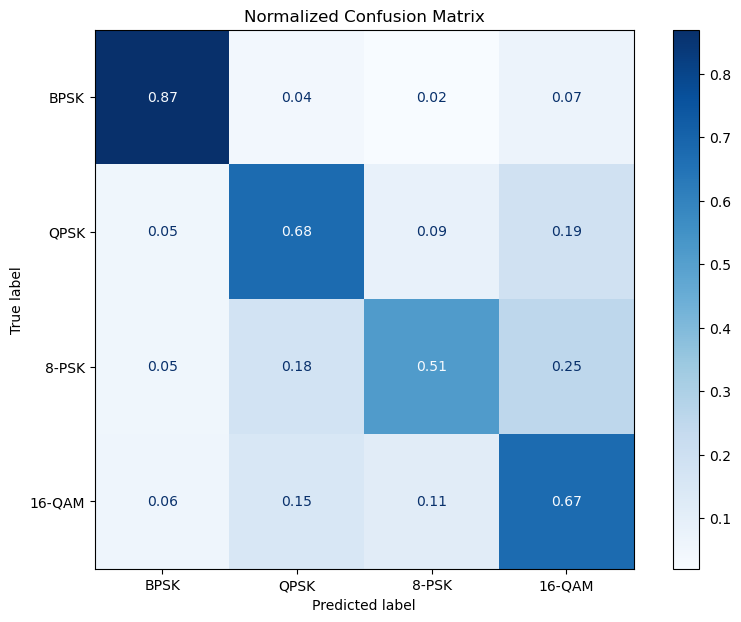

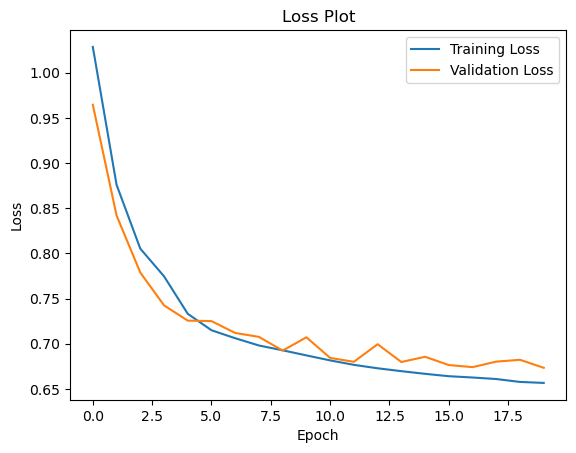

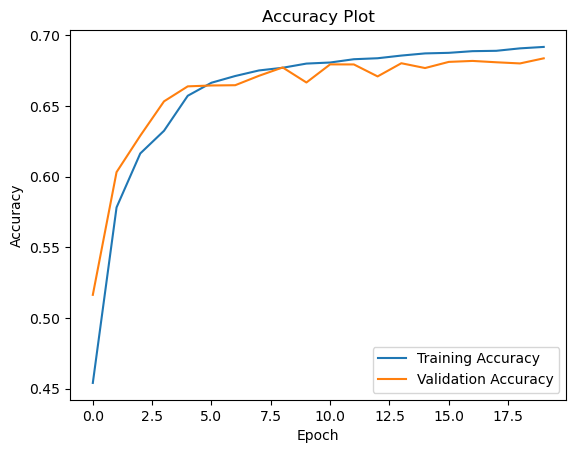

In [11]:
modulation_mapping = {
    0: 'BPSK',
    1: 'QPSK',
    2: '8-PSK',
    3: '16-QAM'
}
# Get the class labels in the order of modulation_mapping
labels = [modulation_mapping[i] for i in range(num_classes)]

def plot_normalized_confusion_matrix(cm, labels):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    fig, ax = plt.subplots(figsize=(10, 7))
    disp.plot(cmap=plt.cm.Blues, ax=ax, values_format=".2f")
    plt.title('Normalized Confusion Matrix')
    plt.show()

cm = confusion_matrix(y_true, y_pred_classes, labels=np.arange(num_classes))
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Print the normalized confusion matrix
print("Normalized Confusion Matrix:")
print(cm_normalized)
plot_normalized_confusion_matrix(cm_normalized, labels)


# Plot loss
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Plot')
plt.legend()
plt.show()


# Plot accuracy
plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Plot')
plt.legend()
plt.show()

626/626 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step


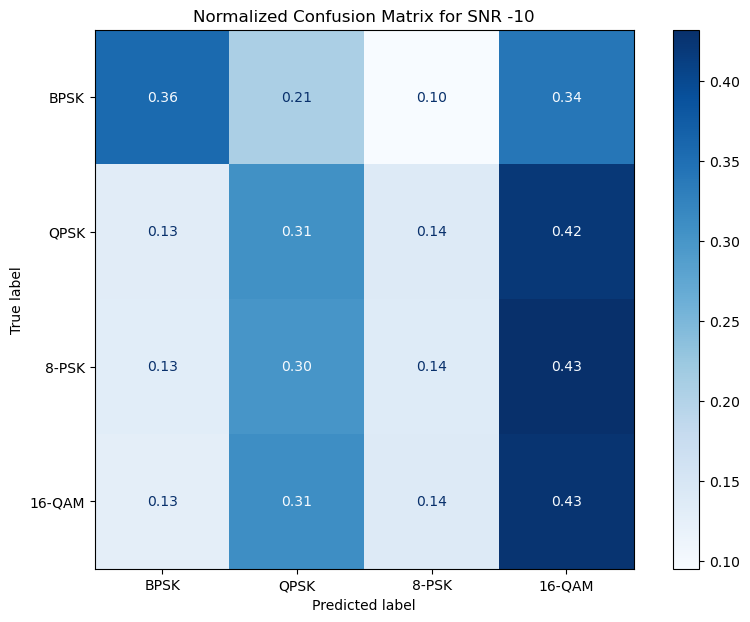

627/627 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step


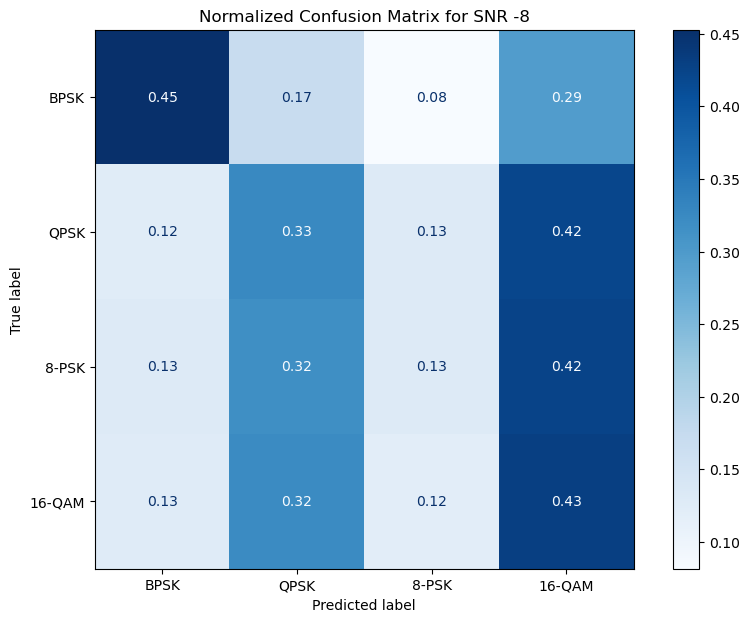

622/622 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step


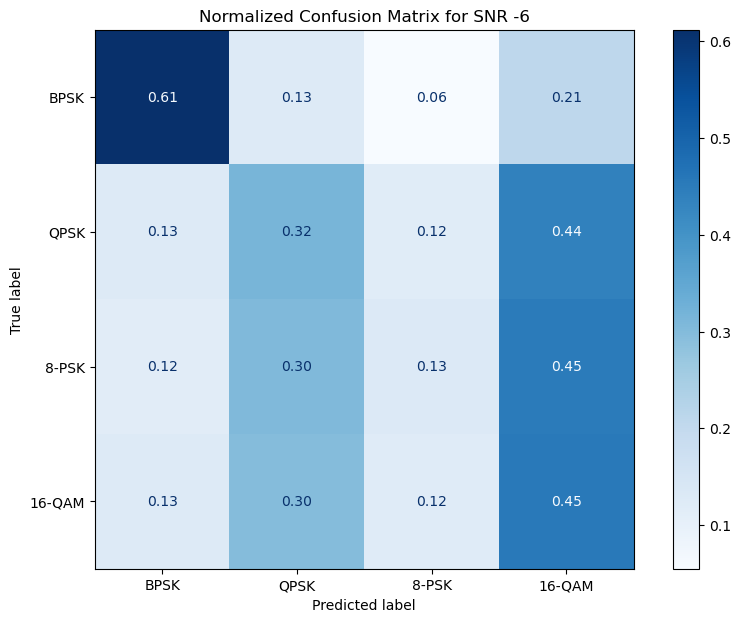

628/628 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step


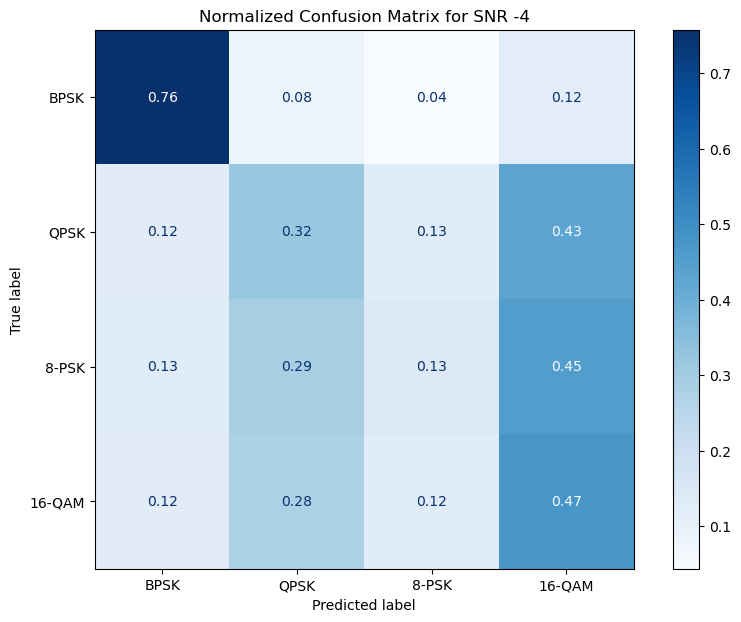

624/624 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step


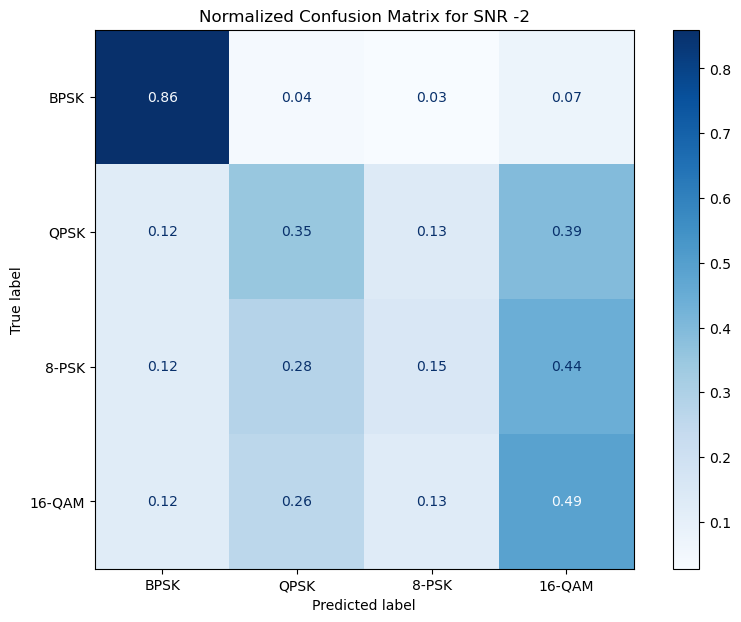

625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step


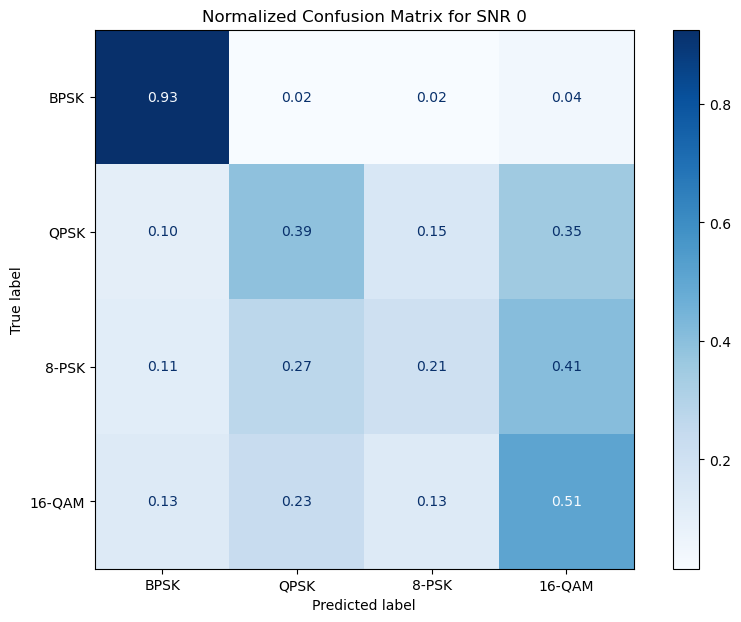

621/621 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step


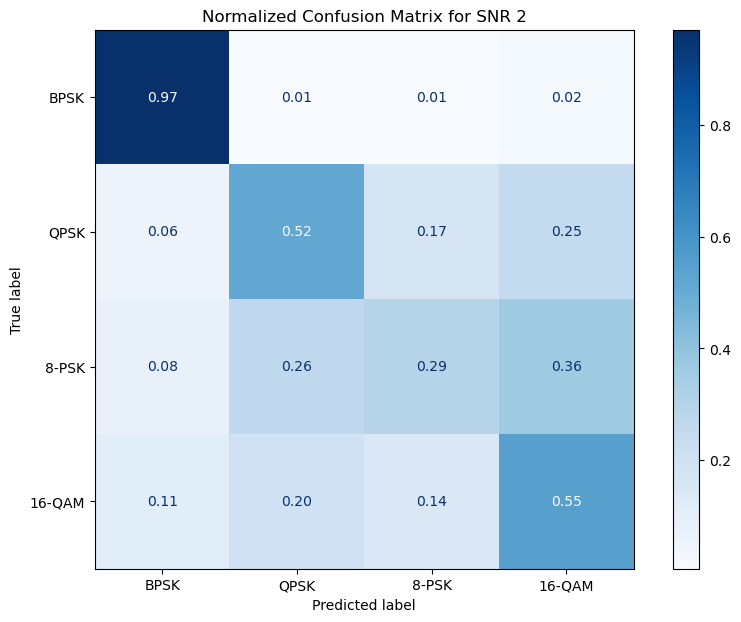

627/627 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step


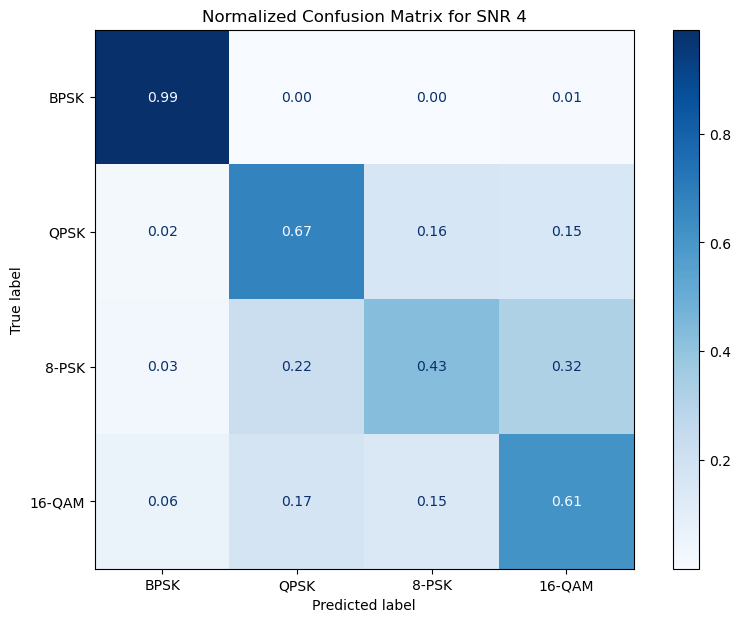

627/627 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step


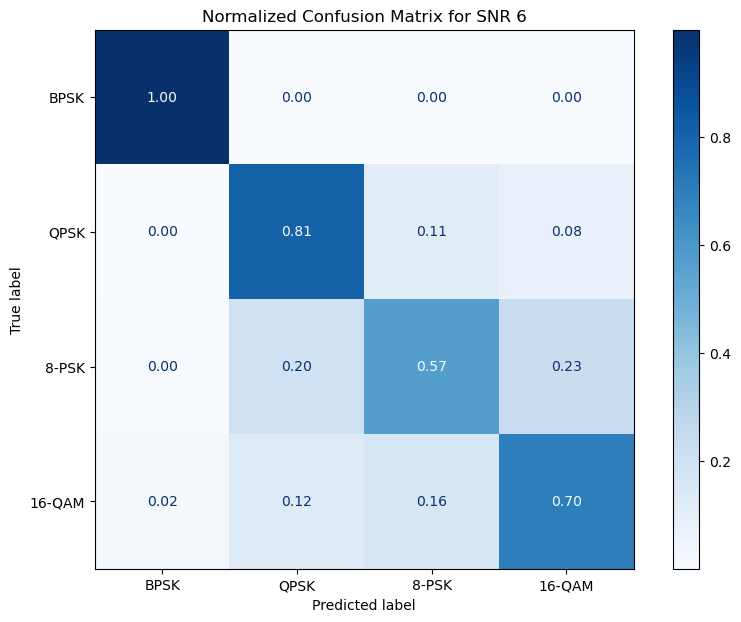

623/623 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step


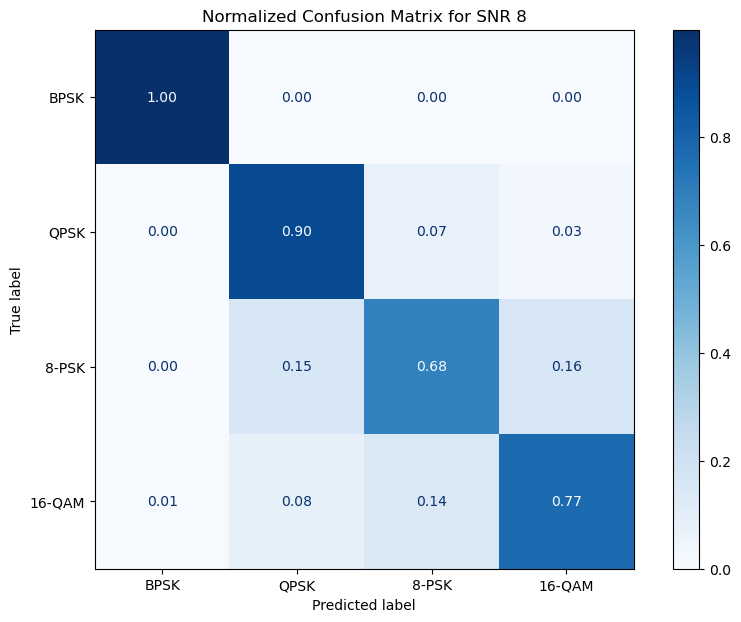

625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step


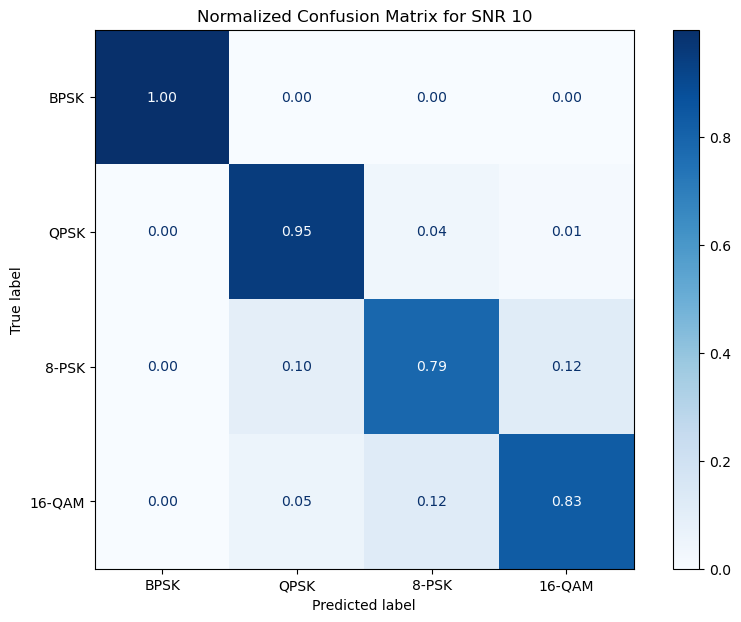

623/623 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step


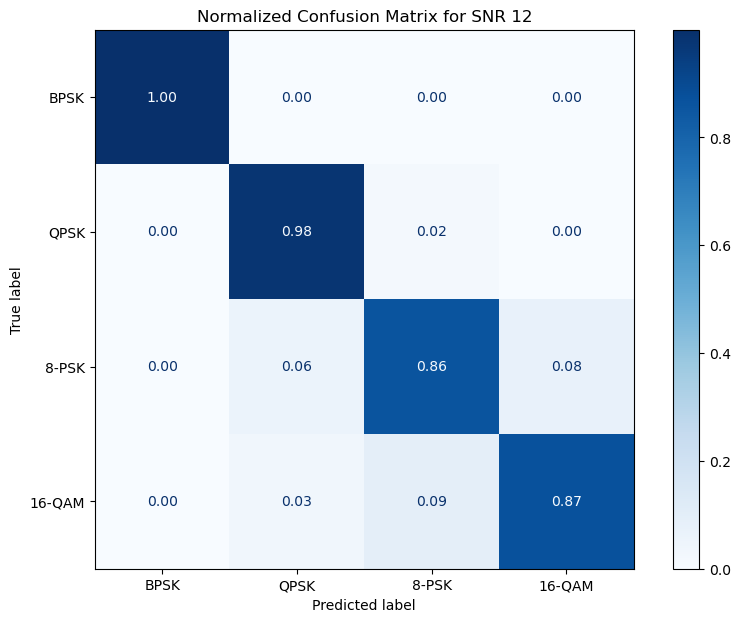

630/630 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step


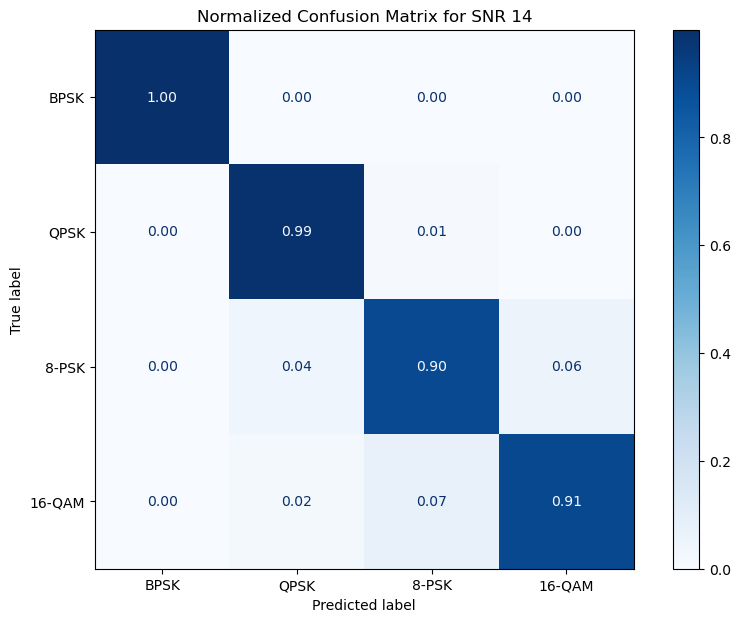

631/631 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step


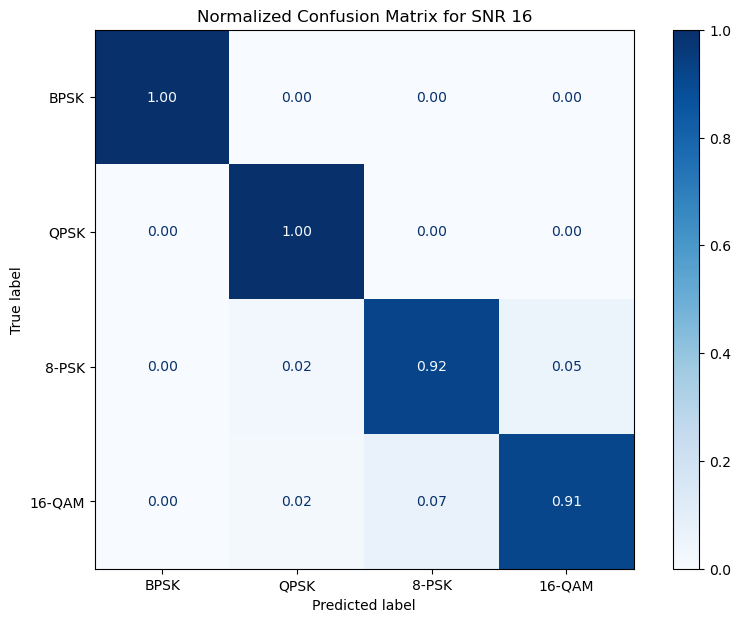

623/623 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step


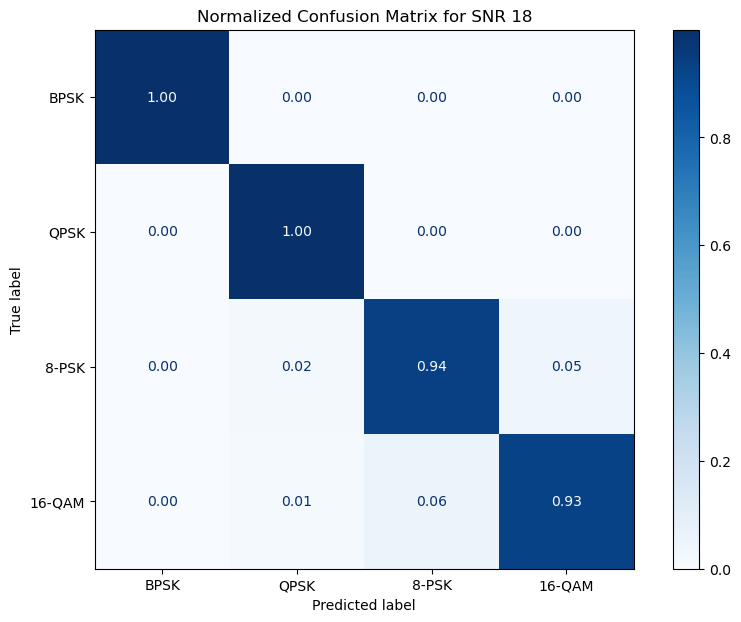

626/626 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step


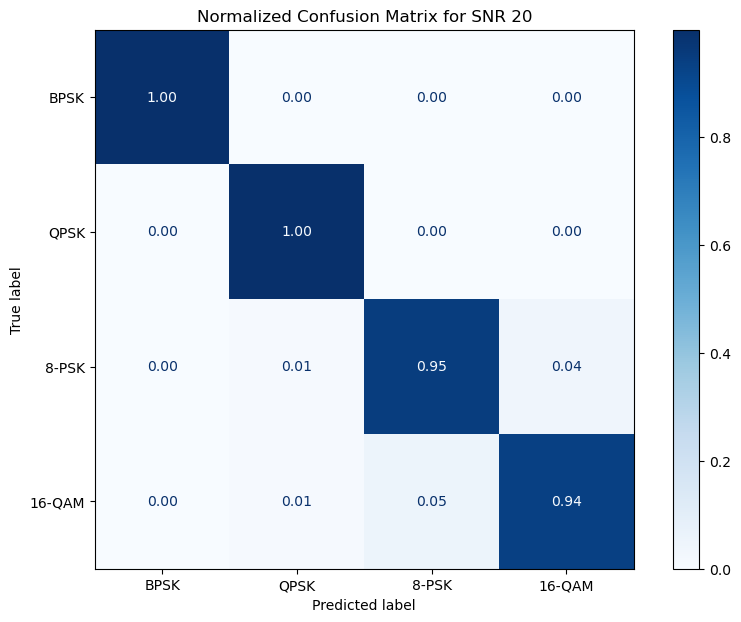

In [12]:
# Evaluate and plot confusion matrix and accuracy for each SNR level
snr_levels = np.unique(snr_test)
accuracy_per_snr = []

for snr_level in snr_levels:
    def plot_normalized_confusion_matrix(cm, labels, title):
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
        fig, ax = plt.subplots(figsize=(10, 7))
        disp.plot(cmap=plt.cm.Blues, ax=ax, values_format=".2f")
        plt.title(title)
        plt.show()
        
    # Get data for this SNR level
    snr_indices = np.where(snr_test == snr_level)
    X_snr = X_test[snr_indices]
    y_snr_true = y_true[snr_indices]
    y_snr_test = y_test[snr_indices]

    # Make predictions
    y_snr_pred = model.predict(X_snr)
    y_snr_pred_classes = np.argmax(y_snr_pred, axis=1)

    # Calculate confusion matrix for this SNR level
    snr_conf_matrix = confusion_matrix(y_snr_true, y_snr_pred_classes, labels=np.arange(num_classes))
    
    # Normalize the confusion matrix by row (true labels)
    snr_conf_matrix_normalized = snr_conf_matrix.astype('float') / snr_conf_matrix.sum(axis=1)[:, np.newaxis]

    plot_normalized_confusion_matrix(snr_conf_matrix_normalized, labels, f'Normalized Confusion Matrix for SNR {snr_level}')

    # Calculate accuracy
    accuracy = np.sum(y_snr_pred_classes == y_snr_true) / len(y_snr_true)
    accuracy_per_snr.append(accuracy)

## Save Model

In [14]:
import pickle
import tensorflow as tf
from tensorflow.keras.models import model_from_json

# Save the model architecture as JSON
model_json = model.to_json()
with open("mr_cnn_model.json", "w") as json_file:
    json_file.write(model_json)

# Save the model weights using pickle
with open("mr_cnn_weights.pkl", "wb") as weights_file:
    pickle.dump(model.get_weights(), weights_file)

print("Model architecture and weights saved successfully.")


Model architecture and weights saved successfully.


In [19]:
# Save the model in HDF5 format
model.save("mr_cnn_model.h5")

# Load the model
loaded_model = tf.keras.models.load_model("mr_cnn_model.h5")

print("Model saved and loaded successfully using .h5 format.")

Model saved and loaded successfully using .h5 format.


## Load Model

In [2]:
import pickle
import tensorflow as tf
from tensorflow.keras.models import model_from_json

# Load the model architecture
with open("mr_cnn_model.json", "r") as json_file:
    loaded_model_json = json_file.read()
loaded_model = model_from_json(loaded_model_json)

# Load the weights
with open("mr_cnn_weights.pkl", "rb") as weights_file:
    loaded_weights = pickle.load(weights_file)
loaded_model.set_weights(loaded_weights)

# Compile the model
loaded_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("Model loaded successfully.")

# Compile the model
loaded_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Show model structure
loaded_model.summary()

FileNotFoundError: [Errno 2] No such file or directory: 'mr_cnn_weights.pkl'

In [1]:
# from tensorflow.keras.models import load_model
# from tensorflow.keras.utils import plot_model

# # Load the model
# model = load_model('mr_cnn_model.h5')

# # Print the model summary
# model.summary()


## Running

In [2]:
import tensorflow as tf
import numpy as np
import h5py
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# Load the trained model
model = tf.keras.models.load_model("mr_cnn_model.h5")
print("Model loaded successfully.")

# File name for dataset
file_name = 'C:/Users/debab/Desktop/IIT+SELF LEARNING/IIT CLASS/BTP/dataset_NOMA_N_800_1_2.h5'

# Load dataset
with h5py.File(file_name, 'r') as hf:
    data_Y = hf['data_Y'][:, :200]
    true_Mods = hf['true_Mods'][:]
    snrs = hf['snrs'][:]

# Convert to numpy arrays
snrs = np.array(snrs)
y = np.array(true_Mods)

# Get unique modulation classes
unique_mods = np.unique(y)
num_classes = len(unique_mods)

# Expand dimensions for CNN input
X = np.expand_dims(data_Y, axis=-1)

# Separate real and imaginary components
X_real = np.real(X)
X_imag = np.imag(X)
X = np.stack((X_real, X_imag), axis=-1)

# Transpose to fit CNN input format
X = np.transpose(X, (0, 3, 1, 2))

# Split into train/test sets
X_train, X_test, y_train, y_test, snr_train, snr_test = train_test_split(X, y, snrs, test_size=0.4)

# Convert labels to one-hot encoding
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

print("X_test shape:", X_test.shape)

# **Run Predictions**
y_pred = model.predict(X_test)

# Convert predicted probabilities to class labels
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Print some sample results
for i in range(10):  # Print first 10 samples
    print(f"True: {y_true[i]}, Predicted: {y_pred_classes[i]}")

# **Evaluate Model Performance**
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Model loaded successfully.
X_test shape: (320000, 2, 200, 1)
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 71s 7ms/step
True: 2, Predicted: 0
True: 3, Predicted: 1
True: 1, Predicted: 2
True: 2, Predicted: 0
True: 3, Predicted: 3
True: 3, Predicted: 2
True: 1, Predicted: 1
True: 0, Predicted: 3
True: 1, Predicted: 1
True: 2, Predicted: 2
Test Loss: 0.6552
Test Accuracy: 0.6920


In [7]:
import tensorflow as tf
import numpy as np
import os
import pandas as pd

# Load the trained model
model = tf.keras.models.load_model("mr_cnn_model.h5")
print("Model loaded successfully.")

# Create a folder to save filter data
save_folder = "CNN_Filters"
os.makedirs(save_folder, exist_ok=True)

# Iterate through model layers
for layer in model.layers:
    if isinstance(layer, tf.keras.layers.Conv2D):
        filters, biases = layer.get_weights()
        num_filters = filters.shape[-1]
        
        # Save each filter separately
        for i in range(num_filters):
            filter_data = filters[:, :, :, i]
            
            # Convert filter to DataFrame
            df = pd.DataFrame(filter_data.reshape(-1, filter_data.shape[-1]))
            
            # Save to Excel
            file_name = os.path.join(save_folder, f"{layer.name}_filter_{i}.xlsx")
            df.to_excel(file_name, index=False)
            print(f"Saved filter {i} of layer {layer.name} to {file_name}")

print("All filters extracted and saved successfully.")


Model loaded successfully.
Saved filter 0 of layer conv2d to CNN_Filters\conv2d_filter_0.xlsx
Saved filter 1 of layer conv2d to CNN_Filters\conv2d_filter_1.xlsx
Saved filter 2 of layer conv2d to CNN_Filters\conv2d_filter_2.xlsx
Saved filter 3 of layer conv2d to CNN_Filters\conv2d_filter_3.xlsx
Saved filter 4 of layer conv2d to CNN_Filters\conv2d_filter_4.xlsx
Saved filter 5 of layer conv2d to CNN_Filters\conv2d_filter_5.xlsx
Saved filter 6 of layer conv2d to CNN_Filters\conv2d_filter_6.xlsx
Saved filter 7 of layer conv2d to CNN_Filters\conv2d_filter_7.xlsx
Saved filter 8 of layer conv2d to CNN_Filters\conv2d_filter_8.xlsx
Saved filter 9 of layer conv2d to CNN_Filters\conv2d_filter_9.xlsx
Saved filter 10 of layer conv2d to CNN_Filters\conv2d_filter_10.xlsx
Saved filter 11 of layer conv2d to CNN_Filters\conv2d_filter_11.xlsx
Saved filter 12 of layer conv2d to CNN_Filters\conv2d_filter_12.xlsx
Saved filter 13 of layer conv2d to CNN_Filters\conv2d_filter_13.xlsx
Saved filter 14 of layer co

In [10]:
import tensorflow as tf
import numpy as np
import os
import pandas as pd

# Load the trained model
model = tf.keras.models.load_model("mr_cnn_model.h5")
print("Model loaded successfully.")

# Create a folder to save filter data
save_folder = "CNN_Filters"
os.makedirs(save_folder, exist_ok=True)

# Iterate through model layers
for layer in model.layers:
    if isinstance(layer, tf.keras.layers.Conv2D):
        filters, biases = layer.get_weights()
        num_filters = filters.shape[-1]
        filter_size = filters.shape[0] * filters.shape[1] * filters.shape[2]  # Flatten each filter
        
        # Reshape filters to have one column per filter and stacked row-wise
        filter_data = filters.reshape(-1, num_filters)
        
        # Convert filter to DataFrame
        df = pd.DataFrame(filter_data)
        
        # Save to Excel
        file_name = os.path.join(save_folder, f"{layer.name}_filters.xlsx")
        df.to_excel(file_name, index=False)
        print(f"Saved all filters of layer {layer.name} to {file_name}")

print("All filters extracted and saved successfully.")

Model loaded successfully.
Saved all filters of layer conv2d to CNN_Filters\conv2d_filters.xlsx
Saved all filters of layer conv2d_1 to CNN_Filters\conv2d_1_filters.xlsx
Saved all filters of layer conv2d_2 to CNN_Filters\conv2d_2_filters.xlsx
Saved all filters of layer conv2d_3 to CNN_Filters\conv2d_3_filters.xlsx
Saved all filters of layer conv2d_4 to CNN_Filters\conv2d_4_filters.xlsx
Saved all filters of layer conv2d_5 to CNN_Filters\conv2d_5_filters.xlsx
Saved all filters of layer conv2d_6 to CNN_Filters\conv2d_6_filters.xlsx
Saved all filters of layer conv2d_7 to CNN_Filters\conv2d_7_filters.xlsx
All filters extracted and saved successfully.


In [4]:
import tensorflow as tf
import os
import numpy as np
import pandas as pd

# Load the trained model
model = tf.keras.models.load_model("mr_cnn_model.h5")
print("Model loaded successfully.")

# Create folder to save filters
save_folder = "CNN_Filters_4"
os.makedirs(save_folder, exist_ok=True)

# Loop through each layer to find Conv2D layers and extract filters + bias
for i, layer in enumerate(model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        filters, biases = layer.get_weights()
        print(f"Layer {i} ({layer.name}) - Filters shape: {filters.shape}, Biases shape: {biases.shape}")

        num_filters = filters.shape[-1]  # Number of output channels
        num_channels = filters.shape[-2]  # Number of input channels

        # Create subfolder for this layer
        layer_folder = os.path.join(save_folder, f"{layer.name}")
        os.makedirs(layer_folder, exist_ok=True)

        # Save each filter and bias in individual Excel files
        for f in range(num_filters):
            data = []
            for c in range(num_channels):
                filter_matrix = filters[:, :, c, f]
                df = pd.DataFrame(filter_matrix)
                df.columns = [f"Ch{c+1}_Col{j+1}" for j in range(df.shape[1])]
                data.append(df)

            result = pd.concat(data, axis=1)
            bias_value = biases[f]

            # Save filter + bias together
            bias_row = pd.DataFrame([[f"Bias: {bias_value}"] + [""] * (result.shape[1] - 1)],
                                    columns=result.columns)
            result_with_bias = pd.concat([result, bias_row], axis=0)
            filter_file = os.path.join(layer_folder, f"{layer.name}_filter_{f+1}.xlsx")
            result_with_bias.to_excel(filter_file, index=False)
            print(f"Saved filter {f+1} with bias of layer {layer.name} to {filter_file}")

            # Save bias separately
            bias_df = pd.DataFrame({"Bias_Value": [bias_value]})
            bias_file = os.path.join(layer_folder, f"{layer.name}_bias_{f+1}.xlsx")
            bias_df.to_excel(bias_file, index=False)
            print(f"Saved bias {f+1} of layer {layer.name} to {bias_file}")


Model loaded successfully.
Layer 1 (conv2d) - Filters shape: (2, 8, 1, 64), Biases shape: (64,)
Saved filter 1 with bias of layer conv2d to CNN_Filters_4\conv2d\conv2d_filter_1.xlsx
Saved bias 1 of layer conv2d to CNN_Filters_4\conv2d\conv2d_bias_1.xlsx
Saved filter 2 with bias of layer conv2d to CNN_Filters_4\conv2d\conv2d_filter_2.xlsx
Saved bias 2 of layer conv2d to CNN_Filters_4\conv2d\conv2d_bias_2.xlsx
Saved filter 3 with bias of layer conv2d to CNN_Filters_4\conv2d\conv2d_filter_3.xlsx
Saved bias 3 of layer conv2d to CNN_Filters_4\conv2d\conv2d_bias_3.xlsx
Saved filter 4 with bias of layer conv2d to CNN_Filters_4\conv2d\conv2d_filter_4.xlsx
Saved bias 4 of layer conv2d to CNN_Filters_4\conv2d\conv2d_bias_4.xlsx
Saved filter 5 with bias of layer conv2d to CNN_Filters_4\conv2d\conv2d_filter_5.xlsx
Saved bias 5 of layer conv2d to CNN_Filters_4\conv2d\conv2d_bias_5.xlsx
Saved filter 6 with bias of layer conv2d to CNN_Filters_4\conv2d\conv2d_filter_6.xlsx
Saved bias 6 of layer conv2d

In [2]:
import tensorflow as tf
import numpy as np
import pandas as pd
import os

# Load the trained model
model = tf.keras.models.load_model("mr_cnn_model.h5")
print("Model loaded successfully.")

# Create a folder to store the extracted weights and biases
save_folder = "Dense_Layer_Weights_Biases"
os.makedirs(save_folder, exist_ok=True)

# Iterate through model layers to find dense layers
for layer in model.layers:
    if isinstance(layer, tf.keras.layers.Dense):
        weights, biases = layer.get_weights()

        # Save weights to an Excel file
        weights_file = os.path.join(save_folder, f"{layer.name}_weights.xlsx")
        weights_df = pd.DataFrame(weights)
        weights_df.to_excel(weights_file, index=False)
        print(f"Saved weights of layer {layer.name} to {weights_file}")

        # Save biases to an Excel file
        biases_file = os.path.join(save_folder, f"{layer.name}_biases.xlsx")
        biases_df = pd.DataFrame(biases)
        biases_df.to_excel(biases_file, index=False)
        print(f"Saved biases of layer {layer.name} to {biases_file}")

print("All dense layer weights and biases extracted and saved successfully.")


Model loaded successfully.
Saved weights of layer dense to Dense_Layer_Weights_Biases\dense_weights.xlsx
Saved biases of layer dense to Dense_Layer_Weights_Biases\dense_biases.xlsx
Saved weights of layer dense_1 to Dense_Layer_Weights_Biases\dense_1_weights.xlsx
Saved biases of layer dense_1 to Dense_Layer_Weights_Biases\dense_1_biases.xlsx
Saved weights of layer dense_2 to Dense_Layer_Weights_Biases\dense_2_weights.xlsx
Saved biases of layer dense_2 to Dense_Layer_Weights_Biases\dense_2_biases.xlsx
All dense layer weights and biases extracted and saved successfully.


In [ ]:
import pandas as pd
import numpy as np
import os

# Define constants
dataWidth = 16  # Total width in bits
intWidth = 4    # Integer width in bits
fracWidth = dataWidth - intWidth  # Fractional width
outputPath = "./"  # Path to save the output files
headerPath = "./"

# DtoB function for two's complement conversion
def DtoB(num, dataWidth, fracBits):  
    if num >= 0:
        num = num * (2**fracBits)
        num = int(num)
        d = num
    else:
        num = -num
        num = num * (2**fracBits)  # Number of fractional bits
        num = int(num)
        if num == 0:
            d = 0
        else:
            d = 2**dataWidth - num
    return d

# Convert the values in the dataframe to binary and save to Excel
def convert_dataframe_to_binary(df, dataWidth, fracWidth):
    binary_df = df.applymap(lambda x: format(DtoB(x, dataWidth, fracWidth), f'0{dataWidth}b'))  # Apply DtoB to all elements
    return binary_df

# List of filter files to convert
# filter_files = [
#     'residual_block_1_main_path.xlsx',
#     'residual_block_1_skip_path.xlsx',
#     'residual_block_2_main_path.xlsx',
#     'residual_block_2_skip_path.xlsx'
# ]
filter_files = [
    "Signal_Test_1.xlsx"
]

# Convert each file and save the binary data to a new Excel file
def convert_and_save_filters(filter_files):
    for filter_file in filter_files:
        # Read the filter values from the Excel file
        df = pd.read_excel(filter_file)
        
        # Convert the filter values to binary
        binary_df = convert_dataframe_to_binary(df, dataWidth, fracWidth)
        
        # Modify the output file name
        output_file = os.path.join(outputPath, f"binary_{filter_file}")
        
        # Save the binary DataFrame to a new Excel file
        binary_df.to_excel(output_file, index=False)
        print(f"Converted values saved to {output_file}")

# Convert and save all filters
convert_and_save_filters(filter_files)


## Save Input Signal with actual VAlue

In [19]:
import pandas as pd

NoSignal = 100  # Number of signals to save
# Select first NoSignal signals and reshape: (NoSignal, 2, 200, 1) → (NoSignal, 400)
X_test_reshaped = X_test[:NoSignal].reshape(NoSignal, -1)

# Convert to DataFrame and save X_test
df_X = pd.DataFrame(X_test_reshaped)
excel_filename_X = f"X_test_{NoSignal}_signals.xlsx"  # Corrected f-string usage
df_X.to_excel(excel_filename_X, index=False)
print(f"First {NoSignal} signals saved to {excel_filename_X}")

# Save corresponding actual labels along with SNR values
df_Y = pd.DataFrame({"Actual Label": y_true[:NoSignal], "SNR": snrs[:NoSignal]})
excel_filename_Y = f"Y_test_{NoSignal}_labels.xlsx"  # Corrected f-string usage
df_Y.to_excel(excel_filename_Y, index=False)
print(f"Actual labels and SNR saved to {excel_filename_Y}")


First 100 signals saved to X_test_100_signals.xlsx
Actual labels and SNR saved to Y_test_100_labels.xlsx


In [5]:
import pandas as pd
import numpy as np  # In case snrs is a NumPy array

NoSignal = 10  # Number of signals to save

# Filter signals where SNR > 0
valid_indices = np.where(snrs > 0)[0]  # Get indices where SNR is positive

# Ensure we have at least NoSignal valid signals
if len(valid_indices) >= NoSignal:
    selected_indices = valid_indices[:NoSignal]  # Pick first NoSignal valid indices

    # Select and reshape corresponding signals
    X_test_reshaped = X_test[selected_indices].reshape(NoSignal, -1)

    # Convert to DataFrame and save X_test
    df_X = pd.DataFrame(X_test_reshaped)
    excel_filename_X = f"X_test_{NoSignal}_signals.xlsx"
    df_X.to_excel(excel_filename_X, index=False)
    print(f"First {NoSignal} signals with SNR > 0 saved to {excel_filename_X}")

    # Save corresponding actual labels along with SNR values
    df_Y = pd.DataFrame({"Actual Label": y_true[selected_indices], "SNR": snrs[selected_indices]})
    excel_filename_Y = f"Y_test_{NoSignal}_labels.xlsx"
    df_Y.to_excel(excel_filename_Y, index=False)
    print(f"Actual labels and SNR saved to {excel_filename_Y}")

else:
    print(f"Error: Only {len(valid_indices)} signals have SNR > 0. Need at least {NoSignal}.")


First 10 signals with SNR > 0 saved to X_test_10_signals.xlsx
Actual labels and SNR saved to Y_test_10_labels.xlsx


In [13]:
import tensorflow as tf
import numpy as np
import h5py
import pandas as pd
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# # Load the trained model
# model = tf.keras.models.load_model("mr_cnn_model.h5")
# print("Model loaded successfully.")

# # File name for dataset
# file_name = 'C:/Users/debab/Desktop/IIT+SELF LEARNING/IIT CLASS/BTP/dataset_NOMA_N_800_1_2.h5'

# # Load dataset
# with h5py.File(file_name, 'r') as hf:
#     data_Y = hf['data_Y'][10000:, :200]
#     true_Mods = hf['true_Mods'][10000:]
#     snrs = hf['snrs'][10000:]

# # Convert to numpy arrays
# snrs = np.array(snrs)
# y = np.array(true_Mods)

# # Get unique modulation classes
# unique_mods = np.unique(y)
# num_classes = len(unique_mods)

# # Expand dimensions for CNN input
# X = np.expand_dims(data_Y, axis=-1)

# # Separate real and imaginary components
# X_real = np.real(X)
# X_imag = np.imag(X)
# X = np.stack((X_real, X_imag), axis=-1)

# # Transpose to fit CNN input format
# X = np.transpose(X, (0, 3, 1, 2))

# # Split dataset (assuming labels are categorical for training purposes)
# X_train, X_test, y_train, y_test, snrs_train, snrs_test = train_test_split(X, y, snrs, test_size=0.2, random_state=42)

NoSignal = 200  # Number of signals to save

# Filter signals where SNR > 0
valid_indices = np.where(snrs_test > 2)[0]  # Get indices where SNR is positive

# Ensure we have at least NoSignal valid signals
if len(valid_indices) >= NoSignal:
    selected_indices = valid_indices[:NoSignal]  # Pick first NoSignal valid indices

    # Select and reshape corresponding signals
    X_test_reshaped = X_test[selected_indices].reshape(NoSignal, -1)

    # Convert to DataFrame and save X_test
    df_X = pd.DataFrame(X_test_reshaped)
    excel_filename_X = f"X_test_{NoSignal}_signals.xlsx"
    df_X.to_excel(excel_filename_X, index=False)
    print(f"First {NoSignal} signals with SNR > 0 saved to {excel_filename_X}")

    # Save corresponding actual labels along with SNR values
    df_Y = pd.DataFrame({"Actual Label": y_test[selected_indices], "SNR": snrs_test[selected_indices]})
    excel_filename_Y = f"Y_test_{NoSignal}_labels.xlsx"
    df_Y.to_excel(excel_filename_Y, index=False)
    print(f"Actual labels and SNR saved to {excel_filename_Y}")

else:
    print(f"Error: Only {len(valid_indices)} signals have SNR > 0. Need at least {NoSignal}.")

Model loaded successfully.
First 200 signals with SNR > 0 saved to X_test_200_signals.xlsx
Actual labels and SNR saved to Y_test_200_labels.xlsx


In [1]:
def binary_to_decimal_4_12(binary_str):
    # Ensure the binary string is 16 bits by padding with zeros
    binary_str = binary_str.zfill(16)
    
    # Extract integer (4 bits) and fractional (12 bits) parts
    int_part = binary_str[:4]
    frac_part = binary_str[4:]
    
    # Convert integer part to decimal
    int_value = int(int_part, 2)
    
    # Convert fractional part to decimal
    frac_value = sum(int(bit) * (2 ** -(i + 1)) for i, bit in enumerate(frac_part))
    
    # Combine integer and fractional parts
    decimal_value = int_value + frac_value
    
    return decimal_value

# Example usage
binary_input = "1100000000000"
padded_binary = binary_input.zfill(16)  # Convert to 16-bit binary
result = binary_to_decimal_4_12(padded_binary)
print("4.12 format decimal value:", result)


4.12 format decimal value: 1.5


## WORKING TESTING

In [3]:
import tensorflow as tf
import pandas as pd
import numpy as np

def load_weights_biases(weight_file, bias_file, expected_input_dim=None):
    weights = pd.read_excel(weight_file, header=None).to_numpy(dtype=np.float32)

    # Ensure there are no extra rows in weights
    if expected_input_dim is not None and weights.shape[0] > expected_input_dim:
        weights = weights[-expected_input_dim:, :]  # Keep only last 'expected_input_dim' rows
    elif expected_input_dim is not None and weights.shape[0] < expected_input_dim:
        raise ValueError(f"Expected input dimension {expected_input_dim}, but got {weights.shape[0]}.")

    biases = pd.read_excel(bias_file, header=None).to_numpy().flatten()

    # Remove non-numeric entries
    biases = np.array([b for b in biases if isinstance(b, (int, float))], dtype=np.float32)

    # Ensure bias shape matches neurons
    biases = biases[:weights.shape[1]]

    return weights, biases


# Define the model
class CustomModel(tf.keras.Model):
    def __init__(self):
        super(CustomModel, self).__init__()
        self.dense1 = tf.keras.layers.Dense(128, activation='relu', name='dense_128', input_shape=(1528,))
        self.dense2 = tf.keras.layers.Dense(24, activation='relu', name='dense_24')
        self.dense3 = tf.keras.layers.Dense(4, activation='softmax', name='dense_4')

    def call(self, inputs):
        x = self.dense1(inputs)
        x = self.dense2(x)
        x = self.dense3(x)
        return x


# Instantiate model
model = CustomModel()

# Run a forward pass with dummy input to initialize layers
dummy_input = np.zeros((1, 1528))  # Updated to 1528 features
_ = model(dummy_input)  # Forward pass

# Load weights and biases with expected dimensions
w1, b1 = load_weights_biases('dense_128_Weights.xlsx', 'dense_128_Biases.xlsx', expected_input_dim=1528)
w2, b2 = load_weights_biases('dense_24_Weights.xlsx', 'dense_24_Biases.xlsx', expected_input_dim=128)
w3, b3 = load_weights_biases('dense_4_Weights.xlsx', 'dense_4_Biases.xlsx', expected_input_dim=24)

# Set custom weights
model.dense1.set_weights([w1, b1])
model.dense2.set_weights([w2, b2])
model.dense3.set_weights([w3, b3])

# Load input data from input_deci.xlsx
# input_file = "output_1.xlsx"
input_file = "dense_binary_test_4.xlsx"
input_data = pd.read_excel(input_file)
# input_data = input_data.iloc[::-1]

# Ensure correct format
input_values = input_data['Decimal Equivalent'].to_numpy(dtype=np.float32)

# Ensure input size matches 1528
if input_values.shape[0] != 1528:
    raise ValueError(f"Expected 1528 input values, but got {input_values.shape[0]}")

# Reshape for model input
input_values = input_values.reshape(1, -1)  # Reshape to (1, 1528) for batch processing

# Run inference
output = model(input_values)

# Print results
print("Model Output:", output.numpy())


C:\Users\debab\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:88: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model Output: [[0.0727229  0.39468393 0.31038696 0.22220626]]


## Extraction and Filter

In [1]:
import pandas as pd

# Load the Excel file
file_path = "X_test_10_signals.xlsx"
df = pd.read_excel(file_path, header=None)

# Skip the first row and iterate through the remaining rows
for i in range(1, len(df)):
    signal = df.iloc[i].to_frame()  # Extract the row as a column (transpose)
    output_file = f"test_{i}.xlsx"
    signal.to_excel(output_file, index=False, header=False)
    print(f"Saved: {output_file}")

Saved: test_1.xlsx
Saved: test_2.xlsx
Saved: test_3.xlsx
Saved: test_4.xlsx
Saved: test_5.xlsx
Saved: test_6.xlsx
Saved: test_7.xlsx
Saved: test_8.xlsx
Saved: test_9.xlsx
Saved: test_10.xlsx


In [9]:
import pandas as pd
import numpy as np
import os

# Define constants
dataWidth = 16  # Total width in bits
intWidth = 4    # Integer width in bits
fracWidth = dataWidth - intWidth  # Fractional width
outputPath = "./"  # Path to save the output files

# DtoB function for two's complement conversion
def DtoB(num, dataWidth, fracBits):  
    if num >= 0:
        num = num * (2**fracBits)
        num = int(num)
        d = num
    else:
        num = -num
        num = num * (2**fracBits)  # Number of fractional bits
        num = int(num)
        if num == 0:
            d = 0
        else:
            d = 2**dataWidth - num
    return d

# Convert the values in the dataframe to binary and save to Excel
def convert_dataframe_to_binary(df, dataWidth, fracWidth):
    binary_df = df.applymap(lambda x: format(DtoB(x, dataWidth, fracWidth), f'0{dataWidth}b'))  # Apply DtoB to all elements
    return binary_df

# List of filter files to convert
filter_files = ["test_4.xlsx"]

# Convert each file and save the binary data to a new Excel file
def convert_and_save_filters(filter_files):
    for filter_file in filter_files:
        # Read the filter values from the Excel file (ensure no header is skipped)
        df = pd.read_excel(filter_file, header=None)  # **Fix: Set header=None**
        
        # Convert the filter values to binary
        binary_df = convert_dataframe_to_binary(df, dataWidth, fracWidth)
        
        # Modify the output file name
        output_file = os.path.join(outputPath, f"binary_{filter_file}")
        
        # Save the binary DataFrame to a new Excel file
        binary_df.to_excel(output_file, index=False, header=False)  # **Fix: No headers**
        print(f"Converted values saved to {output_file}")

# Convert and save all filters
convert_and_save_filters(filter_files)


Converted values saved to ./binary_test_4.xlsx


C:\Users\debab\AppData\Local\Temp\ipykernel_12320\1822181684.py:29: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  binary_df = df.applymap(lambda x: format(DtoB(x, dataWidth, fracWidth), f'0{dataWidth}b'))  # Apply DtoB to all elements


In [10]:
import pandas as pd

# File paths
input_file = "binary_test_4.xlsx"
output_file = "C:/Users/debab/Desktop/IIT+SELF LEARNING/IIT CLASS/BTP/Testing inputs/binary_test_4.mif"

# Read binary values from the Excel file
df = pd.read_excel(input_file, header=None, dtype=str)

# Write only binary values to MIF file
with open(output_file, "w") as f:
    for _, row in df.iterrows():
        binary_value = "".join(row.astype(str))  # Concatenate all binary values in a row
        f.write(f"{binary_value}\n")

print(f"Converted MIF file saved as {output_file}")


Converted MIF file saved as C:/Users/debab/Desktop/IIT+SELF LEARNING/IIT CLASS/BTP/Testing inputs/binary_test_4.mif


In [8]:
import pandas as pd

# Load the CSV file
df = pd.read_csv("op_binary_test_4.csv", header=None, dtype=str)  # Ensure it's read as strings

# Function to convert binary to decimal (scaled by 2^12)
def binaryToDecimal_by2_12(binary_str):
    binary = int(binary_str, 2)  # Convert binary string to integer
    decimal = binary / (2**12)   # Scale down by 2^12
    return decimal

# Process the binary data column-wise, ensuring the first element is included
results = [binaryToDecimal_by2_12(df.iloc[i, 0]) for i in range(df.shape[0])]

# Create a DataFrame with the results
results_df = pd.DataFrame({'Decimal Equivalent': results})

# Save the output to an Excel file
output_filename = "dense_binary_test_4.xlsx"
results_df.to_excel(output_filename, index=False)

print(f"Converted file saved as {output_filename}")


## Time Checking

In [5]:
import numpy as np
import tensorflow as tf
import pandas as pd
import time

# Reset TensorFlow state
tf.keras.backend.clear_session()
# Start timing
start_time = time.time_ns()

# Load the Excel file
file_path = "test_1.xlsx"  # Update with the correct path
df = pd.read_excel(file_path, header=None)

# Extract values from the single-column file
signal_values = df.values.flatten()

# Split into real and imaginary parts
real_part = signal_values[:200]
imag_part = signal_values[200:400]

# Stack them into the required shape for MR-CNN
X_test_single = np.stack((real_part, imag_part), axis=-1)  # Shape (200, 2)

# Expand dimensions to match CNN input format (1 sample, 2 channels, 200 time steps, 1 feature)
X_test_single = np.expand_dims(X_test_single, axis=0)  # (1, 200, 2)
X_test_single = np.transpose(X_test_single, (0, 2, 1))  # Reshape to (1, 2, 200)

# Expand dimensions to fit the CNN expected format (batch_size, channels, height, width)
X_test_single = np.expand_dims(X_test_single, axis=-1)  # (1, 2, 200, 1)

# Load the trained model
model = tf.keras.models.load_model("mr_cnn_model.h5")  # Update with correct path

# Run prediction
y_pred_single = model.predict(X_test_single)

# Convert predicted probabilities to class label
predicted_class = np.argmax(y_pred_single, axis=1)[0]
print(f"Predicted Modulation Class: {predicted_class}")


# End timing
end_time = time.time_ns()
# Compute total execution time in nanoseconds
execution_time_ns = end_time - start_time
print(f"Predicted Modulation Class: {predicted_class}")
print(f"Total Computation Time: {execution_time_ns} ns")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
Predicted Modulation Class: 2
Predicted Modulation Class: 2
Total Computation Time: 531993600 ns


In [6]:
import numpy as np
import tensorflow as tf
import time
from tensorflow.keras import layers, models

# Define the modified residual block
def modified_residual_block(input_tensor):
    main_path = layers.Conv2D(16, (1, 8), activation='relu', padding='same')(input_tensor)
    skip_path = layers.Conv2D(16, (1, 1), activation='relu', padding='same')(input_tensor)
    output = layers.Concatenate()([main_path, skip_path])
    return output

# Create MR-CNN model
def create_mr_cnn(input_shape):
    inputs = layers.Input(shape=input_shape)
    
    x = layers.Conv2D(64, (2, 8), activation='relu', padding='same')(inputs)
    x = layers.Conv2D(32, (2, 4), activation='relu', padding='same')(x)
    x = modified_residual_block(x)
    x = layers.AveragePooling2D(pool_size=(1, 3), strides=1)(x)
    x = layers.Conv2D(16, (1, 3), activation='relu', padding='same')(x)
    x = modified_residual_block(x)
    x = layers.AveragePooling2D(pool_size=(1, 8), strides=1)(x)
    x = layers.Conv2D(8, (1, 3), activation='relu', padding='same')(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(24, activation='relu')(x)
    outputs = layers.Dense(4, activation='softmax')(x)
    
    model = models.Model(inputs=inputs, outputs=outputs)
    return model

# Create model
input_shape = (2, 200, 1)
model = create_mr_cnn(input_shape)

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Generate a random test input signal
X_test_single = np.random.rand(1, 2, 200, 1).astype(np.float32)  # (batch_size=1, channels=2, height=200, width=1)


# Reset TensorFlow state
tf.keras.backend.clear_session()
# Measure prediction time
start_time = time.time_ns()
y_pred_single = model.predict(X_test_single)
end_time = time.time_ns()

# Compute inference time
inference_time_ns = end_time - start_time

# Print results
predicted_class = np.argmax(y_pred_single, axis=1)[0]
print(f"Predicted Modulation Class: {predicted_class}")
print(f"Inference Time: {inference_time_ns} ns")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
Predicted Modulation Class: 2
Inference Time: 244126000 ns


# Individual

In [2]:
import numpy as np
import tensorflow as tf
import pandas as pd
import time

# Reset TensorFlow state
tf.keras.backend.clear_session()
# Start timing
start_time = time.time_ns()

# Load the Excel file
file_path = "test_1.xlsx"  # Update with the correct path
df = pd.read_excel(file_path, header=None)

# Extract values from the single-column file
signal_values = df.values.flatten()

# Split into real and imaginary parts
real_part = signal_values[:200]
imag_part = signal_values[200:400]

# Stack them into the required shape for MR-CNN
X_test_single = np.stack((real_part, imag_part), axis=-1)  # Shape (200, 2)

# Expand dimensions to match CNN input format (1 sample, 2 channels, 200 time steps, 1 feature)
X_test_single = np.expand_dims(X_test_single, axis=0)  # (1, 200, 2)
X_test_single = np.transpose(X_test_single, (0, 2, 1))  # Reshape to (1, 2, 200)

# Expand dimensions to fit the CNN expected format (batch_size, channels, height, width)
X_test_single = np.expand_dims(X_test_single, axis=-1)  # (1, 2, 200, 1)

# Load the trained model
model = tf.keras.models.load_model("mr_cnn_model.h5")  # Update with correct path

# Run prediction
y_pred_single = model.predict(X_test_single)

# Convert predicted probabilities to class label
predicted_class = np.argmax(y_pred_single, axis=1)[0]
print(f"Predicted Modulation Class: {predicted_class}")


# End timing
end_time = time.time_ns()
# Compute total execution time in nanoseconds
execution_time_ns = end_time - start_time
print(f"Predicted Modulation Class: {predicted_class}")
print(f"Total Computation Time: {execution_time_ns} ns")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step
Predicted Modulation Class: 2
Predicted Modulation Class: 2
Total Computation Time: 482822300 ns


Filter shape: (2, 8, 1, 64)
Bias shape: (64,)
Bias values: [-6.6155759e-03 -6.3753268e-03  1.1694714e-03 -2.4918888e-03
 -3.7501726e-02 -9.1963550e-03  1.3242534e-03 -4.3571438e-03
 -1.8455908e-02 -7.8757936e-03 -1.0486912e-02 -1.3906147e-01
 -3.2322926e-03  1.6908688e-03 -1.3623923e-03 -2.0409117e-03
 -1.5339856e-03 -1.6136643e-01 -2.5247263e-03 -3.0118753e-03
 -9.4947135e-03 -8.6456146e-03 -3.1629018e-02 -2.9828586e-03
 -7.4014803e-03 -4.2682136e-03 -9.4485877e-04  3.8667809e-04
 -3.6887098e-03 -5.5383490e-03 -3.3392531e-03 -8.3368896e-03
 -1.4215193e-04 -7.5643589e-03 -6.4909579e-03 -2.7053934e-03
 -1.0203648e-02 -2.7709141e-02 -7.0592523e-02 -6.1505781e-03
 -3.5817181e-03 -6.9218753e-03 -9.8514333e-02 -9.3965782e-03
 -4.6426086e-03 -2.5843242e-02 -1.9003924e-02 -1.1615869e-02
  4.5518996e-04 -3.3504225e-03 -2.9534760e-03 -1.0080530e-03
 -6.1267982e-03  7.7189662e-04 -9.7276215e-03 -1.0857969e-03
 -4.8145889e-03 -5.4166204e-04 -2.6574077e-03  3.0516426e-04
 -1.5447397e-03 -2.8511158

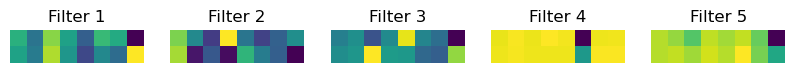

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Feature Map shape: (1, 2, 200, 64)


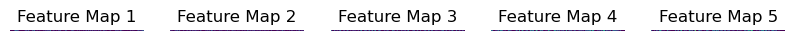

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
Predicted Modulation Class: 2
Raw Output Probabilities: [[1.1406277e-10 5.4207117e-06 9.6531981e-01 3.4674738e-02]]


In [19]:
import numpy as np
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt

# Load the Excel file
file_path = "test_1.xlsx"  # Update with the correct path
df = pd.read_excel(file_path, header=None)

# Extract values from the single-column file
signal_values = df.values.flatten()

# Split into real and imaginary parts
real_part = signal_values[:200]
imag_part = signal_values[200:400]

# Stack them into the required shape for MR-CNN
X_test_single = np.stack((real_part, imag_part), axis=-1)  # Shape (200, 2)

# Expand dimensions to match CNN input format
X_test_single = np.expand_dims(X_test_single, axis=0)  # (1, 200, 2)
X_test_single = np.transpose(X_test_single, (0, 2, 1))  # Reshape to (1, 2, 200)
X_test_single = np.expand_dims(X_test_single, axis=-1)  # (1, 2, 200, 1)

# Load the trained model
model = tf.keras.models.load_model("mr_cnn_model.h5")  # Update with correct path

# Get the first convolutional layer (index 1 because index 0 is the input layer)
conv_layer = model.layers[1]  # Assuming first layer is Conv2D
filters, biases = conv_layer.get_weights()  # Get filter weights and biases

print(f"Filter shape: {filters.shape}")  # Should be (kernel_x, kernel_y, input_channels, output_channels)
print(f"Bias shape: {biases.shape}")
print(f"Bias values: {biases}")

# Visualize the first few filters
plt.figure(figsize=(10, 3))
num_filters = min(filters.shape[-1], 5)  # Show up to 5 filters
for i in range(num_filters):
    plt.subplot(1, num_filters, i + 1)
    plt.imshow(filters[:, :, 0, i], cmap="viridis")  # Selecting first input channel
    plt.axis("off")
    plt.title(f"Filter {i+1}")
plt.show()

# Run intermediate model to get feature maps
intermediate_model = tf.keras.Model(inputs=model.input, outputs=conv_layer.output)
feature_maps = intermediate_model.predict(X_test_single)

print(f"Feature Map shape: {feature_maps.shape}")  # Should be (1, height, width, num_filters)

# Visualize feature maps
plt.figure(figsize=(10, 3))
num_feature_maps = min(feature_maps.shape[-1], 5)  # Show up to 5 feature maps
for i in range(num_feature_maps):
    plt.subplot(1, num_feature_maps, i + 1)
    plt.imshow(feature_maps[0, :, :, i], cmap="viridis")
    plt.axis("off")
    plt.title(f"Feature Map {i+1}")
plt.show()

# Predict modulation class
y_pred_single = model.predict(X_test_single)
predicted_class = np.argmax(y_pred_single, axis=1)[0]

print(f"Predicted Modulation Class: {predicted_class}")
print(f"Raw Output Probabilities: {y_pred_single}")


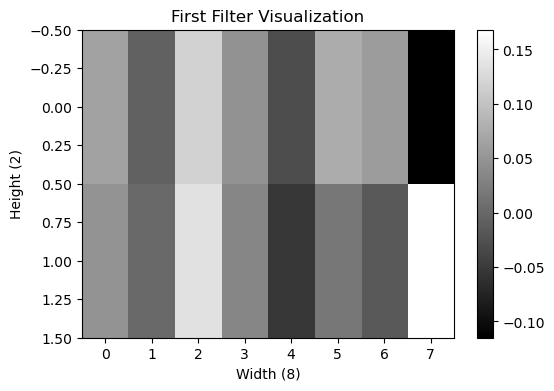

In [18]:
import matplotlib.pyplot as plt

# Extract the filters (weights) from the first Conv2D layer
filters, biases = model.layers[1].get_weights()  # First Conv2D layer (index 1)

# Select the first filter (0th index)
first_filter = filters[:, :, 0, 0]  # Extracting the first filter

# Plot the filter
plt.figure(figsize=(6, 4))
plt.imshow(first_filter, cmap='gray', aspect='auto')
plt.colorbar()
plt.title("First Filter Visualization")
plt.xlabel("Width (8)")
plt.ylabel("Height (2)")
plt.show()


## ALL FILTERS

In [20]:
import numpy as np
import tensorflow as tf
import pandas as pd

# Load the Excel file
file_path = "test_1.xlsx"  # Update with the correct path
df = pd.read_excel(file_path, header=None)

# Extract values from the single-column file
signal_values = df.values.flatten()

# Split into real and imaginary parts
real_part = signal_values[:200]
imag_part = signal_values[200:400]

# Stack them into the required shape for MR-CNN
X_test_single = np.stack((real_part, imag_part), axis=-1)  # Shape (200, 2)

# Expand dimensions to match CNN input format
X_test_single = np.expand_dims(X_test_single, axis=0)  # (1, 200, 2)
X_test_single = np.transpose(X_test_single, (0, 2, 1))  # Reshape to (1, 2, 200)
X_test_single = np.expand_dims(X_test_single, axis=-1)  # (1, 2, 200, 1)

# Load the trained model
model = tf.keras.models.load_model("mr_cnn_model.h5")  # Update with correct path

# Get the first convolutional layer (assuming it's the first Conv2D layer)
conv_layer = model.layers[1]  # Change index if needed
filters, biases = conv_layer.get_weights()  # Get filter weights and biases

# Print filter details
print(f"Filter shape: {filters.shape}")  # (kernel_x, kernel_y, input_channels, output_channels)
print(f"Bias shape: {biases.shape}")
print(f"Bias values:\n{biases}")

# Print filter values
num_filters = filters.shape[-1]
for i in range(num_filters):
    print(f"\nFilter {i+1} values:\n", filters[:, :, :, i])

# Run intermediate model to get feature maps
intermediate_model = tf.keras.Model(inputs=model.input, outputs=conv_layer.output)
feature_maps = intermediate_model.predict(X_test_single)

print(f"\nFeature Map shape: {feature_maps.shape}")  # (1, height, width, num_filters)

# Print feature maps values
num_feature_maps = feature_maps.shape[-1]
for i in range(num_feature_maps):
    print(f"\nFeature Map {i+1} values:\n", feature_maps[0, :, :, i])

# Predict modulation class
y_pred_single = model.predict(X_test_single)
predicted_class = np.argmax(y_pred_single, axis=1)[0]

print(f"\nPredicted Modulation Class: {predicted_class}")
print(f"Raw Output Probabilities:\n{y_pred_single}")


Filter shape: (2, 8, 1, 64)
Bias shape: (64,)
Bias values:
[-6.6155759e-03 -6.3753268e-03  1.1694714e-03 -2.4918888e-03
 -3.7501726e-02 -9.1963550e-03  1.3242534e-03 -4.3571438e-03
 -1.8455908e-02 -7.8757936e-03 -1.0486912e-02 -1.3906147e-01
 -3.2322926e-03  1.6908688e-03 -1.3623923e-03 -2.0409117e-03
 -1.5339856e-03 -1.6136643e-01 -2.5247263e-03 -3.0118753e-03
 -9.4947135e-03 -8.6456146e-03 -3.1629018e-02 -2.9828586e-03
 -7.4014803e-03 -4.2682136e-03 -9.4485877e-04  3.8667809e-04
 -3.6887098e-03 -5.5383490e-03 -3.3392531e-03 -8.3368896e-03
 -1.4215193e-04 -7.5643589e-03 -6.4909579e-03 -2.7053934e-03
 -1.0203648e-02 -2.7709141e-02 -7.0592523e-02 -6.1505781e-03
 -3.5817181e-03 -6.9218753e-03 -9.8514333e-02 -9.3965782e-03
 -4.6426086e-03 -2.5843242e-02 -1.9003924e-02 -1.1615869e-02
  4.5518996e-04 -3.3504225e-03 -2.9534760e-03 -1.0080530e-03
 -6.1267982e-03  7.7189662e-04 -9.7276215e-03 -1.0857969e-03
 -4.8145889e-03 -5.4166204e-04 -2.6574077e-03  3.0516426e-04
 -1.5447397e-03 -2.8511158

In [22]:
import numpy as np
import tensorflow as tf
import pandas as pd

# Load the Excel file
file_path = "test_1.xlsx"  # Update with the correct path
df = pd.read_excel(file_path, header=None)

# Extract values from the single-column file
signal_values = df.values.flatten()

# Split into real and imaginary parts
real_part = signal_values[:200]
imag_part = signal_values[200:400]

# Stack them into the required shape for MR-CNN
X_test_single = np.stack((real_part, imag_part), axis=-1)  # Shape (200, 2)

# Expand dimensions to match CNN input format
X_test_single = np.expand_dims(X_test_single, axis=0)  # (1, 200, 2)
X_test_single = np.transpose(X_test_single, (0, 2, 1))  # Reshape to (1, 2, 200)
X_test_single = np.expand_dims(X_test_single, axis=-1)  # (1, 2, 200, 1)

# Load the trained model
model = tf.keras.models.load_model("mr_cnn_model.h5")  # Update with correct path

# Get the first convolutional layer (assuming it's the first Conv2D layer)
conv_layer = model.layers[1]  
filters, biases = conv_layer.get_weights()  # Get filter weights and biases

# Print filter details
print(f"Filter shape: {filters.shape}")  # (kernel_x, kernel_y, input_channels, output_channels)
print(f"Bias shape: {biases.shape}")
print(f"Bias values:\n{biases}")

# Extract filter dimensions
kernel_x, kernel_y, in_channels, out_channels = filters.shape

# Manually apply convolution for the first filter
stride = 1  # Default stride (change if different)
input_data = X_test_single[0, :, :, 0]  # Shape (2, 200)

# Output dimensions calculation
output_height = (input_data.shape[0] - kernel_x) // stride + 1
output_width = (input_data.shape[1] - kernel_y) // stride + 1
output_matrix = np.zeros((output_height, output_width))

# Apply convolution operation for first filter
for i in range(output_height):
    for j in range(output_width):
        region = input_data[i:i+kernel_x, j:j+kernel_y]  # Extract correct region
        output_matrix[i, j] = np.sum(region * filters[:, :, 0, 0]) + biases[0]

print("\nInput Matrix (First Channel):\n", input_data)
print("\nOutput Feature Map after Convolution:\n", output_matrix)

# Run intermediate model to get feature maps
intermediate_model = tf.keras.Model(inputs=model.input, outputs=conv_layer.output)
feature_maps = intermediate_model.predict(X_test_single)

print(f"\nFeature Map shape: {feature_maps.shape}")  # (1, height, width, num_filters)

# Print first feature map values
print(f"\nFeature Map (First Filter) Values:\n", feature_maps[0, :, :, 0])

# Predict modulation class
y_pred_single = model.predict(X_test_single)
predicted_class = np.argmax(y_pred_single, axis=1)[0]

print(f"\nPredicted Modulation Class: {predicted_class}")
print(f"Raw Output Probabilities:\n{y_pred_single}")


Filter shape: (2, 8, 1, 64)
Bias shape: (64,)
Bias values:
[-6.6155759e-03 -6.3753268e-03  1.1694714e-03 -2.4918888e-03
 -3.7501726e-02 -9.1963550e-03  1.3242534e-03 -4.3571438e-03
 -1.8455908e-02 -7.8757936e-03 -1.0486912e-02 -1.3906147e-01
 -3.2322926e-03  1.6908688e-03 -1.3623923e-03 -2.0409117e-03
 -1.5339856e-03 -1.6136643e-01 -2.5247263e-03 -3.0118753e-03
 -9.4947135e-03 -8.6456146e-03 -3.1629018e-02 -2.9828586e-03
 -7.4014803e-03 -4.2682136e-03 -9.4485877e-04  3.8667809e-04
 -3.6887098e-03 -5.5383490e-03 -3.3392531e-03 -8.3368896e-03
 -1.4215193e-04 -7.5643589e-03 -6.4909579e-03 -2.7053934e-03
 -1.0203648e-02 -2.7709141e-02 -7.0592523e-02 -6.1505781e-03
 -3.5817181e-03 -6.9218753e-03 -9.8514333e-02 -9.3965782e-03
 -4.6426086e-03 -2.5843242e-02 -1.9003924e-02 -1.1615869e-02
  4.5518996e-04 -3.3504225e-03 -2.9534760e-03 -1.0080530e-03
 -6.1267982e-03  7.7189662e-04 -9.7276215e-03 -1.0857969e-03
 -4.8145889e-03 -5.4166204e-04 -2.6574077e-03  3.0516426e-04
 -1.5447397e-03 -2.8511158

In [25]:
import numpy as np

# Input matrix (2x10) - Single channel
input_matrix = np.array([
    [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],  # Row 1
    [5, 4, 3, 2, 1, 0, -1, -2, -3, -4] # Row 2
])

# (2x4) Convolution Filter (Example filter)
conv_filter = np.array([
    [1, 0, -1, 2], 
    [-1, 2, 0, 1]
])

# Stride = 1, Same padding
N = input_matrix.shape[1]  # Number of columns
filter_width = 4
output = []  # Store convolution results

# Sliding window operation
for i in range(N):  # Sliding across the width
    if i + filter_width > N:  # Avoid overflow
        break
    
    window = input_matrix[:, i:i+filter_width]  # Extract 2x4 region
    conv_result = np.sum(window * conv_filter)  # Element-wise multiply and sum
    output.append(conv_result)

# Convert to numpy array
output = np.array(output)

# Print Input
print("Input Matrix (2xN):")
print(input_matrix)

# Print Filter
print("\nConvolution Filter (2x4):")
print(conv_filter)

# Print Sliding Window Results
print("\nSliding Window Results (Each step):")
for i in range(len(output)):
    print(f"Step {i+1}: {output[i]}")

# Print Final Output
print("\nFinal Output After Convolution (1xN):")
print(output)


Input Matrix (2xN):
[[ 1  2  3  4  5  6  7  8  9 10]
 [ 5  4  3  2  1  0 -1 -2 -3 -4]]

Convolution Filter (2x4):
[[ 1  0 -1  2]
 [-1  2  0  1]]

Sliding Window Results (Each step):
Step 1: 11
Step 2: 11
Step 3: 11
Step 4: 11
Step 5: 11
Step 6: 11
Step 7: 11

Final Output After Convolution (1xN):
[11 11 11 11 11 11 11]


In [1]:
import numpy as np

# Input (2x10) - Single Channel
input_matrix = np.array([
    [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],  
    [5, 4, 3, 2, 1, 0, -1, -2, -3, -4]  
])

# Kernel (2x4)
conv_filter = np.array([
    [1, 0, -1, 2], 
    [-1, 2, 0, 1]
])

# Apply 'same' padding (pad with zeros to maintain width)
pad_size = (4 - 1) // 2  # Padding needed for width to remain N
padded_input = np.pad(input_matrix, ((0, 0), (pad_size, pad_size)), mode='constant', constant_values=0)

# Output array
N = input_matrix.shape[1]  # Width
output = []

# Convolution operation
for i in range(N):  
    if i + 4 > padded_input.shape[1]:  # Ensure valid window extraction
        break
    
    window = padded_input[:, i:i+4]  # Extract 2x4 region
    conv_result = np.sum(window * conv_filter)  # Apply filter
    output.append(conv_result)

output = np.array(output)

# Print
print("Padded Input (2xN with zero-padding):")
print(padded_input)

# Print Filter
print("\nConvolution Filter (2x4):")
print(conv_filter)

print("\nFinal Output After Convolution (1xN):")
print(output)


Padded Input (2xN with zero-padding):
[[ 0  1  2  3  4  5  6  7  8  9 10  0]
 [ 0  5  4  3  2  1  0 -1 -2 -3 -4  0]]

Convolution Filter (2x4):
[[ 1  0 -1  2]
 [-1  2  0  1]]

Final Output After Convolution (1xN):
[17 11 11 11 11 11 11 11 -6]


In [5]:
import numpy as np

# Step 1: Define the Input Matrix (2x10)
input_matrix = np.array([
    [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],  
    [5, 4, 3, 2, 1, 0, -1, -2, -3, -4]  
])

# Step 2: Define the Kernel/Filter (2x4)
conv_filter = np.array([
    [1,  0, -1,  2],  
    [-1, 2,  0,  1]  
])

# Step 3: Apply 'same' Padding (Width padding required)
kernel_height, kernel_width = conv_filter.shape
pad_width = (kernel_width - 1) // 2  # (4-1) // 2 = 1
padded_input = np.pad(input_matrix, ((0, 0), (pad_width, pad_width)), mode='constant', constant_values=0)

# Step 4: Perform Convolution (Keeping output as 2x10)
N = input_matrix.shape[1]  # Width of input
output = np.zeros((2, N))  # Preserve 2-row structure

for i in range(N):  
    if i + kernel_width <= padded_input.shape[1]:  # Ensure valid slice
        window = padded_input[:, i:i+kernel_width]  # Extract (2x4) region
        conv_result = np.sum(window * conv_filter, axis=1)  # Apply filter row-wise
        output[:, i] = conv_result  # Store in corresponding row

# Step 5: Print Results
print("\n🔹 Original Input Matrix (2x10):")
print(input_matrix)

print("\n🔹 Applied Zero Padding (2x12) for 'same' Convolution:")
print(padded_input)

print("\n🔹 Convolution Kernel (2x4):")
print(conv_filter)

print("\n🔹 Output After Convolution (2x10) - Same Height Maintained:")
print(output)



🔹 Original Input Matrix (2x10):
[[ 1  2  3  4  5  6  7  8  9 10]
 [ 5  4  3  2  1  0 -1 -2 -3 -4]]

🔹 Applied Zero Padding (2x12) for 'same' Convolution:
[[ 0  1  2  3  4  5  6  7  8  9 10  0]
 [ 0  5  4  3  2  1  0 -1 -2 -3 -4  0]]

🔹 Convolution Kernel (2x4):
[[ 1  0 -1  2]
 [-1  2  0  1]]

🔹 Output After Convolution (2x10) - Same Height Maintained:
[[ 4.  6.  8. 10. 12. 14. 16. 18. -2.  0.]
 [13.  5.  3.  1. -1. -3. -5. -7. -4.  0.]]


In [12]:
import numpy as np
from scipy.signal import convolve2d

# Define Input Matrix (2xN)
N = 10  # Change N as needed
input_matrix = np.array([
    [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],  
    [5, 4, 3, 2, 1, 0, -1, -2, -3, -4]  
])

# Define Filter (1x3)
conv_filter = np.array([[1, 0, -1]])  # A simple edge-detection filter

# Apply padding to the input manually (1 column of zeros on each side)
padded_input = np.pad(input_matrix, ((0, 0), (1, 1)), mode='constant', constant_values=0)

# Perform Convolution with 'same' padding
output_matrix = np.zeros_like(input_matrix)
for i in range(2):  # Iterate over height
    output_matrix[i] = convolve2d(input_matrix[i:i+1], conv_filter, mode='same', boundary='fill', fillvalue=0)

# Print Matrices
print("🔹 Input Matrix (2xN):")
print(input_matrix)

print("\n🔹 Padded Input Matrix (2x(N+2)):")
print(padded_input)

print("\n🔹 Convolution Filter (1x3):")
print(conv_filter)

print("\n🔹 Output Matrix After Convolution (2xN):")
print(output_matrix)


🔹 Input Matrix (2xN):
[[ 1  2  3  4  5  6  7  8  9 10]
 [ 5  4  3  2  1  0 -1 -2 -3 -4]]

🔹 Padded Input Matrix (2x(N+2)):
[[ 0  1  2  3  4  5  6  7  8  9 10  0]
 [ 0  5  4  3  2  1  0 -1 -2 -3 -4  0]]

🔹 Convolution Filter (1x3):
[[ 1  0 -1]]

🔹 Output Matrix After Convolution (2xN):
[[ 2  2  2  2  2  2  2  2  2 -9]
 [ 4 -2 -2 -2 -2 -2 -2 -2 -2  3]]
